# MethodResults Visualiser

Interactive visualiser for the Week 2 competition results stored in `MethodResults/`.

Each `.npz` file is one **case** (e.g. `SparseImpulseInput_Case1`). Inside, every key is a
**participant** whose value is a dict with:

- `latent_states` — array `(T, latent_dim)`
- `inputs` — array `(T, input_dim)`

There is **no ground truth** stored here, so this notebook compares participants against each other.
The recovered **inputs** are directly comparable across participants. The recovered **latent states**
are only identifiable up to a linear transform, so an optional least-squares alignment to a reference
participant is provided to make latent overlays meaningful.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

RESULTS_DIR = Path("MethodResults")
plt.rcParams["figure.figsize"] = (11, 4)

## Loading utilities

In [3]:
def list_case_files(results_dir=RESULTS_DIR):
    """Return sorted list of case .npz paths."""
    return sorted(Path(results_dir).glob("*.npz"))


def load_case(case_name):
    """Load one case -> {participant: {"latent_states": ndarray, "inputs": ndarray}}."""
    path = CASES[case_name]
    data = np.load(path, allow_pickle=True)
    return {name: data[name].item() for name in data.files}


# Map of human-readable case name -> file path
CASES = {p.stem: p for p in list_case_files()}

print(f"Found {len(CASES)} cases in {RESULTS_DIR}/:")
for name in CASES:
    sample = load_case(name)
    any_p = next(iter(sample))
    T, k = np.asarray(sample[any_p]["latent_states"]).shape
    print(f"  {name:32s}  participants={len(sample):2d}  T={T:3d}  latent_dim={k}")

Found 18 cases in MethodResults/:
  MinEnergyInput_Case1              participants=16  T=200  latent_dim=3
  MinEnergyInput_Case2              participants=16  T=200  latent_dim=3
  MinEnergyInput_Case3              participants=16  T=200  latent_dim=4
  MinEnergyInput_Case4              participants=16  T=200  latent_dim=4
  SparseImpulseInput_Case1          participants=16  T=200  latent_dim=3
  SparseImpulseInput_Case10         participants=15  T= 10  latent_dim=3
  SparseImpulseInput_Case11         participants=16  T=100  latent_dim=2
  SparseImpulseInput_Case12         participants=16  T=100  latent_dim=8
  SparseImpulseInput_Case13         participants=13  T=100  latent_dim=3
  SparseImpulseInput_Case14         participants=16  T=200  latent_dim=3
  SparseImpulseInput_Case2          participants=16  T=200  latent_dim=3
  SparseImpulseInput_Case3          participants=16  T=200  latent_dim=3
  SparseImpulseInput_Case4          participants=16  T=100  latent_dim=2
  SparseImpulseIn

## Latent alignment helper

Latent states are identifiable only up to a linear transform. This finds the least-squares linear map taking a participant's latents onto a chosen reference participant's latents, so the overlay is comparable.

In [4]:
def align_latents(reference, estimate):
    """Least-squares linear map of `estimate` (T, k) onto `reference` (T, k).

    Solves  estimate @ W ~= reference  and returns estimate @ W.
    Falls back to the raw estimate if shapes are incompatible.
    """
    reference = np.asarray(reference)
    estimate = np.asarray(estimate)
    if estimate.shape[0] != reference.shape[0]:
        return estimate
    W, *_ = np.linalg.lstsq(estimate, reference, rcond=None)
    return estimate @ W

## Plot: recovered inputs

Overlays the recovered input signal(s) from every selected participant. This is the most directly comparable quantity.

In [5]:
def plot_inputs(case_name, participants=None):
    case = load_case(case_name)
    if participants is None:
        participants = list(case)
    participants = [p for p in participants if p in case]
    if not participants:
        print("No participants selected.")
        return

    input_dim = np.asarray(case[participants[0]]["inputs"]).shape[1]
    fig, axes = plt.subplots(input_dim, 1, figsize=(11, 3 * input_dim), squeeze=False)

    for d in range(input_dim):
        ax = axes[d, 0]
        for name in participants:
            u = np.asarray(case[name]["inputs"])
            ax.plot(u[:, d], label=name, alpha=0.8, lw=1.4)
        ax.set_title(f"{case_name} — recovered input dim {d}")
        ax.set_xlabel("time step")
        ax.set_ylabel(f"u[{d}]")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2, loc="best")

    fig.tight_layout()
    plt.show()

## Plot: recovered latent states

One subplot per latent dimension, overlaying selected participants. Enable `align` to map each participant's latents onto the reference participant via least squares.

In [6]:
def plot_latents(case_name, participants=None, align=False, reference=None):
    case = load_case(case_name)
    if participants is None:
        participants = list(case)
    participants = [p for p in participants if p in case]
    if not participants:
        print("No participants selected.")
        return

    if reference is None or reference not in case:
        reference = participants[0]
    ref_latents = np.asarray(case[reference]["latent_states"])

    k = ref_latents.shape[1]
    fig, axes = plt.subplots(k, 1, figsize=(11, 2.4 * k), squeeze=False, sharex=True)

    for name in participants:
        x = np.asarray(case[name]["latent_states"])
        if align and name != reference and x.shape[1] == k:
            x = align_latents(ref_latents, x)
        for d in range(min(k, x.shape[1])):
            axes[d, 0].plot(x[:, d], label=name, alpha=0.8, lw=1.2)

    for d in range(k):
        ax = axes[d, 0]
        ax.set_ylabel(f"x[{d}]")
        ax.grid(True, alpha=0.3)
    suffix = f"  (aligned to {reference})" if align else ""
    axes[0, 0].set_title(f"{case_name} — recovered latent states{suffix}")
    axes[0, 0].legend(fontsize=7, ncol=2, loc="best")
    axes[-1, 0].set_xlabel("time step")
    fig.tight_layout()
    plt.show()

## Plot: single participant detail

Inputs and all latent dimensions for one participant.

In [7]:
def plot_participant(case_name, participant):
    case = load_case(case_name)
    if participant not in case:
        print(f"{participant} not in {case_name}.")
        return
    u = np.asarray(case[participant]["inputs"])
    x = np.asarray(case[participant]["latent_states"])

    fig, axes = plt.subplots(2, 1, figsize=(11, 7))
    for d in range(u.shape[1]):
        axes[0].plot(u[:, d], label=f"u[{d}]")
    axes[0].set_title(f"{case_name} — {participant}: inputs")
    axes[0].set_ylabel("input")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    for d in range(x.shape[1]):
        axes[1].plot(x[:, d], label=f"x[{d}]")
    axes[1].set_title(f"{participant}: latent states")
    axes[1].set_xlabel("time step")
    axes[1].set_ylabel("latent")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## Interactive dashboard

Pick a case, select participants, and choose what to view. Participant choices update automatically when the case changes.

In [ ]:
case_dd = widgets.Dropdown(options=list(CASES), description="Case:")
participant_sel = widgets.SelectMultiple(description="Who:", rows=10)
view_rb = widgets.RadioButtons(
    options=["inputs", "latents", "both", "single participant"],
    value="inputs", description="View:",
)
align_cb = widgets.Checkbox(value=True, description="align latents")
ref_dd = widgets.Dropdown(description="ref:")


def _refresh_participants(*_):
    case = load_case(case_dd.value)
    names = list(case)
    participant_sel.options = names
    participant_sel.value = tuple(names)  # select all by default
    ref_dd.options = names
    if names:
        ref_dd.value = names[0]


case_dd.observe(_refresh_participants, names="value")
_refresh_participants()


def _render(case_name, participants, view, align, reference):
    participants = list(participants)
    if not participants:
        print("Select at least one participant.")
        return
    if view == "inputs":
        plot_inputs(case_name, participants)
    elif view == "latents":
        plot_latents(case_name, participants, align=align, reference=reference)
    elif view == "both":
        plot_inputs(case_name, participants)
        plot_latents(case_name, participants, align=align, reference=reference)
    elif view == "single participant":
        plot_participant(case_name, participants[0])


out = widgets.interactive_output(
    _render,
    {
        "case_name": case_dd,
        "participants": participant_sel,
        "view": view_rb,
        "align": align_cb,
        "reference": ref_dd,
    },
)

controls = widgets.VBox([
    case_dd,
    widgets.HBox([participant_sel, widgets.VBox([view_rb, align_cb, ref_dd])]),
])
display(controls, out)

## Quick non-interactive examples

Useful if `ipywidgets` is not rendering (e.g. plain export).

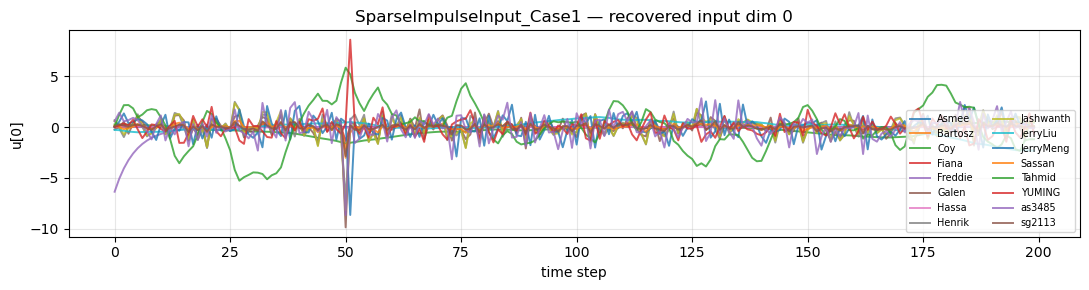

In [ ]:
# Overlay all participants' inputs for one case
plot_inputs("SparseImpulseInput_Case1")


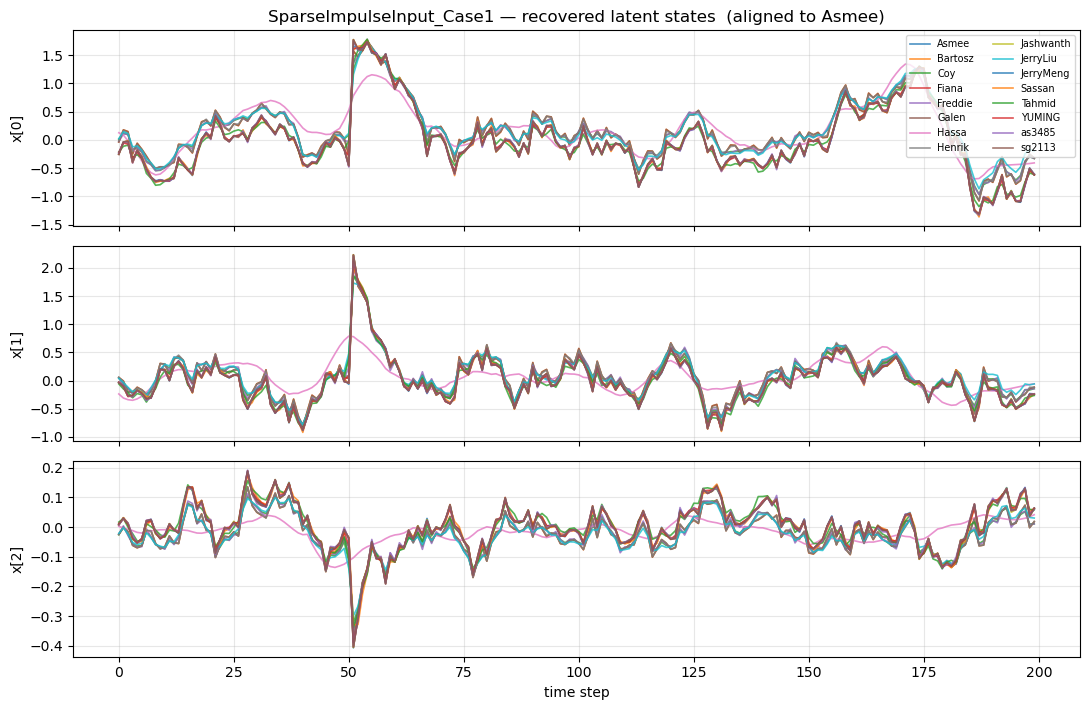

In [ ]:
# Overlay latent states, aligned to a reference participant
plot_latents("SparseImpulseInput_Case1", align=True)